In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("../data_files/executions.csv")
df.head()

# use concat to combine datasets, deal with null values somehow

,First Name,Last Name,Middle Name(s),Suffix,Race,Sex,Age,Foreign National,Juvenile,Federal,...,Number of Asian Male Victims,Number of Native American Male Victims,Number of Other Race Male Victims,Number of White Female Victims,Number of Black Female Victims,Number of Latino Female Victims,Number of Asian Female Victims,Number of American Indian or Alaska Native Female Victims,Number of Other Race Female Victims,Victim Races Includes White
0,Gary,Gilmore,Mark,NaN,White,Male,36,No,No,No,...,0,0,0,0,0,0,0,0,0,Yes
1,John,Spenkelink,NaN,NaN,White,Male,30,No,No,No,...,0,0,0,0,0,0,0,0,0,Yes
2,Jesse,Bishop,NaN,NaN,White,Male,46,No,No,No,...,0,0,0,0,0,0,0,0,0,Yes
3,Steven,Judy,Timothy,NaN,White,Male,24,No,No,No,...,0,0,0,2,0,0,0,0,0,Yes
4,Frank,Coppola,NaN,NaN,White,Male,38,No,No,No,...,0,0,0,0,0,0,0,0,0,Yes


### Figuring out the data I'm working with

In [3]:
df.columns
# can I consolidate the victim columns?

Index(['First Name', 'Last Name', 'Middle Name(s)', 'Suffix', 'Race', 'Sex',
       'Age', 'Foreign National', 'Juvenile', 'Federal', 'Region', 'Country',
       'State', 'County', 'Execution Date', 'Method', 'Victims',
       'Victim Races', 'Number of Victims', 'Number of Male Victims',
       'Number of Female Victims', 'Number of White Male Victims',
       'Number of Black Male Victims', 'Number of Latino Male Victims',
       'Number of Asian Male Victims',
       'Number of Native American Male Victims',
       'Number of Other Race Male Victims', 'Number of White Female Victims',
       'Number of Black Female Victims', 'Number of Latino Female Victims',
       'Number of Asian Female Victims',
       'Number of American Indian or Alaska Native Female Victims',
       'Number of Other Race Female Victims', 'Victim Races Includes White'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1661 entries, 0 to 1660
Data columns (total 34 columns):
 #   Column                                                     Non-Null Count  Dtype
---  ------                                                     --------------  -----
 0   First Name                                                 1661 non-null   str  
 1   Last Name                                                  1661 non-null   str  
 2   Middle Name(s)                                             1022 non-null   str  
 3   Suffix                                                     109 non-null    str  
 4   Race                                                       1659 non-null   str  
 5   Sex                                                        1661 non-null   str  
 6   Age                                                        1661 non-null   int64
 7   Foreign National                                           1661 non-null   str  
 8   Juvenile                               

In [5]:
df.describe(include='all')

,First Name,Last Name,Middle Name(s),Suffix,Race,Sex,Age,Foreign National,Juvenile,Federal,...,Number of Asian Male Victims,Number of Native American Male Victims,Number of Other Race Male Victims,Number of White Female Victims,Number of Black Female Victims,Number of Latino Female Victims,Number of Asian Female Victims,Number of American Indian or Alaska Native Female Victims,Number of Other Race Female Victims,Victim Races Includes White
count,1661,1661,1022,109,1659,1661,1661.000000,1661,1661,1661,...,1661.000000,1661.000000,1661.000000,1661.000000,1661.000000,1661.000000,1661.000000,1661.000000,1661.000000,1661
unique,500,1126,323,5,6,2,NaN,2,2,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,Robert,Johnson,Lee,Jr.,White,Male,NaN,No,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes
freq,70,29,76,87,931,1643,NaN,1627,1639,1645,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1300
mean,NaN,NaN,NaN,NaN,NaN,NaN,43.029500,NaN,NaN,NaN,...,0.015653,0.001806,0.001806,0.550271,0.109573,0.037327,0.007827,0.003010,0.001204,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,10.319812,NaN,NaN,NaN,...,0.133518,0.054852,0.042473,0.725214,0.410743,0.229832,0.106698,0.064868,0.034690,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,22.000000,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,42.000000,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,50.000000,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


In [6]:
df.describe()

,Age,Number of Victims,Number of Male Victims,Number of Female Victims,Number of White Male Victims,Number of Black Male Victims,Number of Latino Male Victims,Number of Asian Male Victims,Number of Native American Male Victims,Number of Other Race Male Victims,Number of White Female Victims,Number of Black Female Victims,Number of Latino Female Victims,Number of Asian Female Victims,Number of American Indian or Alaska Native Female Victims,Number of Other Race Female Victims
count,1661.000000,1661.000000,1661.000000,1661.000000,1661.000000,1661.000000,1661.000000,1661.000000,1661.000000,1661.000000,1661.000000,1661.000000,1661.000000,1661.000000,1661.000000,1661.000000
mean,43.029500,1.443107,0.733895,0.709211,0.535822,0.112583,0.065021,0.015653,0.001806,0.001806,0.550271,0.109573,0.037327,0.007827,0.003010,0.001204
std,10.319812,1.005968,0.893882,0.770131,0.800271,0.456510,0.309467,0.133518,0.054852,0.042473,0.725214,0.410743,0.229832,0.106698,0.064868,0.034690
min,22.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,42.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,50.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,83.000000,16.000000,12.000000,10.000000,12.000000,6.000000,5.000000,2.000000,2.000000,1.000000,10.000000,5.000000,4.000000,2.000000,2.000000,1.000000


In [7]:
df.value_counts()

First Name  Last Name   Middle Name(s)  Suffix  Race   Sex   Age  Foreign National  Juvenile  Federal  Region   Country        State           County              Execution Date  Method            Victims                                       Victim Races  Number of Victims  Number of Male Victims  Number of Female Victims  Number of White Male Victims  Number of Black Male Victims  Number of Latino Male Victims  Number of Asian Male Victims  Number of Native American Male Victims  Number of Other Race Male Victims  Number of White Female Victims  Number of Black Female Victims  Number of Latino Female Victims  Number of Asian Female Victims  Number of American Indian or Alaska Native Female Victims  Number of Other Race Female Victims  Victim Races Includes White
John        Gardner     Sterling        Jr.     White  Male  34   No                No        No       South    United States  North Carolina  Forsyth County      10/23/1992      Lethal Injection  1 White Female, 1 White Male

In [8]:
df['Foreign National'].value_counts()

Foreign National
No     1627
Yes      34
Name: count, dtype: int64

In [9]:
df['Juvenile'].value_counts()

Juvenile
No     1639
Yes      22
Name: count, dtype: int64

### Exploring juvenile cases

In [10]:
df[df['Juvenile'] == 'Yes'][['Race', 'Age', 'Sex', 'Region', 'Victims', 'Number of Victims', 'Victim Races', 'Number of Male Victims', 'Number of Female Victims']]

,Race,Age,Sex,Region,Victims,Number of Victims,Victim Races,Number of Male Victims,Number of Female Victims
47,White,28,Male,South,1 White Male,1,White,1,0
50,White,25,Male,South,"1 White Female, 1 White Male",2,White,1,1
56,White,24,Male,South,2 White Females,2,White,0,2
127,Black,30,Male,South,1 White Male,1,White,1,0
160,White,28,Male,South,1 White Female,1,White,0,1
206,Black,31,Male,South,1 White Male,1,White,1,0
208,Black,29,Male,Midwest,1 Black Female,1,Black,0,1
213,Latino/a,26,Male,South,1 Latino/a Male,1,Latino/a,1,0
223,White,33,Male,South,1 White Male,1,White,1,0
454,White,38,Male,South,1 White Female,1,White,0,1


In [11]:
df['Method'].value_counts()

Method
Lethal Injection    1470
Electrocution        163
Gas                   19
Firing Squad           6
Hanging                3
Name: count, dtype: int64

In [12]:
df['Race'].value_counts()

Race
White                               931
Black                               563
Latino/a                            135
American Indian or Alaska Native     21
Asian                                 6
Other Race                            3
Name: count, dtype: int64

In [13]:
df['Number of Victims'].describe()

count    1661.000000
mean        1.443107
std         1.005968
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        16.000000
Name: Number of Victims, dtype: float64

### Dropping redundant columns

In [14]:
df = df.drop(columns=['Number of White Male Victims',
       'Number of Black Male Victims', 'Number of Latino Male Victims',
       'Number of Asian Male Victims',
       'Number of Native American Male Victims',
       'Number of Other Race Male Victims', 'Number of White Female Victims',
       'Number of Black Female Victims', 'Number of Latino Female Victims',
       'Number of Asian Female Victims',
       'Number of American Indian or Alaska Native Female Victims',
       'Number of Other Race Female Victims', 'Victim Races Includes White'])
df.head()

,First Name,Last Name,Middle Name(s),Suffix,Race,Sex,Age,Foreign National,Juvenile,Federal,...,Country,State,County,Execution Date,Method,Victims,Victim Races,Number of Victims,Number of Male Victims,Number of Female Victims
0,Gary,Gilmore,Mark,NaN,White,Male,36,No,No,No,...,United States,Utah,Utah County,01/17/1977,Firing Squad,1 White Male,White,1,1,0
1,John,Spenkelink,NaN,NaN,White,Male,30,No,No,No,...,United States,Florida,Leon County,05/25/1979,Electrocution,1 White Male,White,1,1,0
2,Jesse,Bishop,NaN,NaN,White,Male,46,No,No,No,...,United States,Nevada,Clark County,10/22/1979,Gas,1 White Male,White,1,1,0
3,Steven,Judy,Timothy,NaN,White,Male,24,No,No,No,...,United States,Indiana,Morgan County,03/09/1981,Electrocution,"2 White Females, 2 White Males",White,4,2,2
4,Frank,Coppola,NaN,NaN,White,Male,38,No,No,No,...,United States,Virginia,Newport News city,08/10/1982,Electrocution,1 White Male,White,1,1,0


### Moved middle name column

In [15]:
col_to_move = df.pop('Middle Name(s)')
df.insert(1, 'Middle Name(s)', col_to_move)
df.head()

,First Name,Middle Name(s),Last Name,Suffix,Race,Sex,Age,Foreign National,Juvenile,Federal,...,Country,State,County,Execution Date,Method,Victims,Victim Races,Number of Victims,Number of Male Victims,Number of Female Victims
0,Gary,Mark,Gilmore,NaN,White,Male,36,No,No,No,...,United States,Utah,Utah County,01/17/1977,Firing Squad,1 White Male,White,1,1,0
1,John,NaN,Spenkelink,NaN,White,Male,30,No,No,No,...,United States,Florida,Leon County,05/25/1979,Electrocution,1 White Male,White,1,1,0
2,Jesse,NaN,Bishop,NaN,White,Male,46,No,No,No,...,United States,Nevada,Clark County,10/22/1979,Gas,1 White Male,White,1,1,0
3,Steven,Timothy,Judy,NaN,White,Male,24,No,No,No,...,United States,Indiana,Morgan County,03/09/1981,Electrocution,"2 White Females, 2 White Males",White,4,2,2
4,Frank,NaN,Coppola,NaN,White,Male,38,No,No,No,...,United States,Virginia,Newport News city,08/10/1982,Electrocution,1 White Male,White,1,1,0


In [16]:
df.columns

Index(['First Name', 'Middle Name(s)', 'Last Name', 'Suffix', 'Race', 'Sex',
       'Age', 'Foreign National', 'Juvenile', 'Federal', 'Region', 'Country',
       'State', 'County', 'Execution Date', 'Method', 'Victims',
       'Victim Races', 'Number of Victims', 'Number of Male Victims',
       'Number of Female Victims'],
      dtype='str')

### Interested in cases with high number of victims

In [17]:
df[df['Number of Victims'] > 5]

,First Name,Middle Name(s),Last Name,Suffix,Race,Sex,Age,Foreign National,Juvenile,Federal,...,Country,State,County,Execution Date,Method,Victims,Victim Races,Number of Victims,Number of Male Victims,Number of Female Victims
43,Marvin,NaN,Francois,NaN,Black,Male,39,No,No,No,...,United States,Florida,Miami-Dade County,05/29/1985,Electrocution,6 Black Males,Black,6,6,0
87,Beauford,James,White,NaN,Black,Male,41,No,No,No,...,United States,Florida,Miami-Dade County,08/28/1987,Electrocution,6 Black Males,Black,6,6,0
130,Ronald,Gene,Simmons,NaN,White,Male,49,No,No,No,...,United States,Arkansas,Pope County,06/25/1990,Lethal Injection,"6 White Males, 10 White Females",White,16,6,10
236,John,Wayne,Gacy,NaN,White,Male,52,No,No,No,...,United States,Illinois,Cook County,05/10/1994,Lethal Injection,12 White Males,White,12,12,0
287,Roger,Dale,Stafford,NaN,White,Male,43,No,No,No,...,United States,Oklahoma,McClain County,07/01/1995,Lethal Injection,"3 White Males, 1 White Female, 1 Latino/a Male...","White, Latino/a, Black",6,5,1
321,William,George,Bonin,NaN,White,Male,49,No,No,No,...,United States,California,Los Angeles County,02/23/1996,Lethal Injection,"9 White Males, 1 Latino/a Male","White, Latino/a",10,10,0
636,Robert,Earl,Carter,NaN,Black,Male,34,No,No,No,...,United States,Texas,Bastrop County,05/31/2000,Lethal Injection,"5 Black Females, 1 Black Male",Black,6,1,5
716,Timothy,James,McVeigh,NaN,White,Male,33,No,No,Yes,...,United States,Oklahoma,Oklahoma County,06/11/2001,Lethal Injection,"7 White Males, 1 White Female",White,8,7,1
851,Carl,Junior,Isaacs,NaN,White,Male,49,No,No,No,...,United States,Georgia,Seminole County,05/06/2003,Lethal Injection,"5 White Males, 1 White Female",White,6,5,1
1319,Manuel,NaN,Pardo,Jr.,Latino/a,Male,56,No,No,No,...,United States,Florida,Miami-Dade County,12/11/2012,Lethal Injection,"1 White Male, 5 Latino/a Males, 3 Latino/a Fem...","White, Latino/a",9,6,3


In [18]:
df['Number of Victims'].value_counts()

Number of Victims
1     1224
2      268
3      105
4       39
5       12
6        6
8        2
16       1
12       1
10       1
9        1
7        1
Name: count, dtype: int64

### Number of victims
- May try to make "greater than 4 victims" into 1 category for a visualization
- Might be better as a percentage
- Showing that vast majority of offenders committed crime against 1 victim

<Axes: xlabel='Number of Victims'>

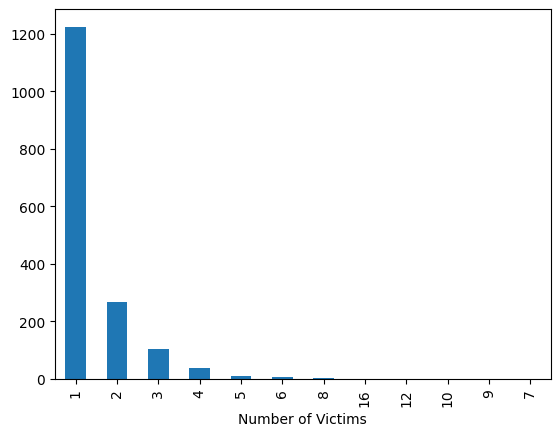

In [19]:
df['Number of Victims'].value_counts().plot.bar()
# How to tell what percent of offenders had 1 vic, 2 vics, etc?
# Try to put numbers in order

### Age Distribution at Time of Execution
Comparing this distribution to historical dataset; will concatenate

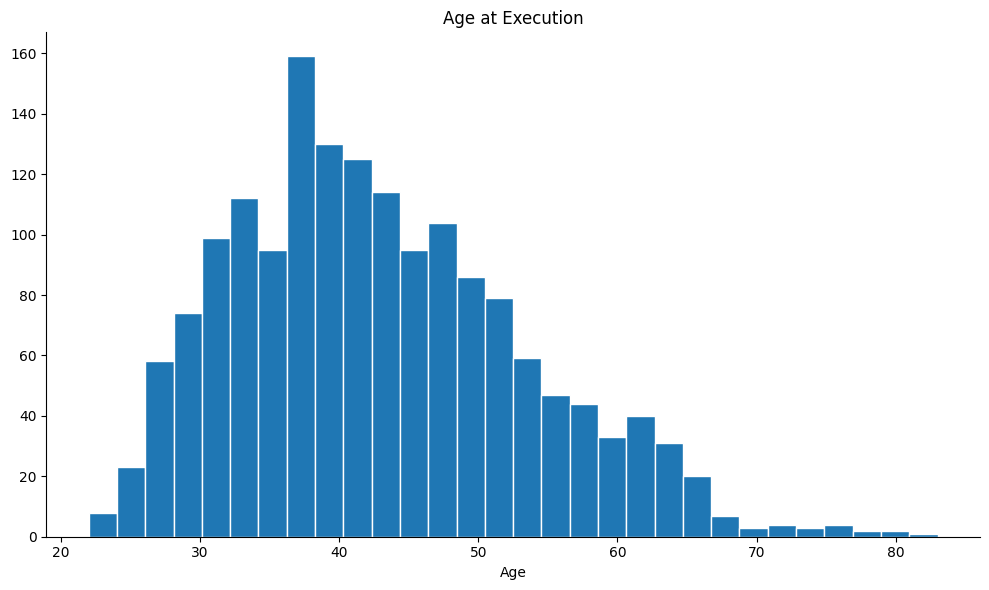

In [20]:
plt.figure(figsize=(10,6))
plt.hist(
    df["Age"],
    edgecolor = "white",
    bins = 30
)

plt.xlabel("Age")
plt.title("Age at Execution")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [21]:
df['Age'].describe()

count    1661.000000
mean       43.029500
std        10.319812
min        22.000000
25%        35.000000
50%        42.000000
75%        50.000000
max        83.000000
Name: Age, dtype: float64